# **Experiment-3**  - Wine Dataset

**AIM:** To implement the KNN algorithm for classification and demonstrate the process of finding out optimal "K"
value using Python Programming.

**Description of the Algorithm:**

* K-Nearest Neighbors is a supervised learning algorithm used for classification. It classifies a test data point by finding the K nearest data points from the training dataset based on a distance metric (Euclidean distance). The class which occurs most frequently among the K neighbors is assigned to the test data point.

**Step 1: Import Libraries**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

**Step 2: Mount Google Drive & Load a Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Datasets/wine.csv")
df.head()

Mounted at /content/drive


**Step 3: Preprocessing**

In [ ]:
print("shape of the dataset:", df.shape)
print("Number of columns:", len(df.columns))
# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())
# Check missing values
print("Missing values per column:\n", df.isnull().sum())

shape of the dataset: (178, 13)
Number of columns: 13
Number of duplicate rows: 0
Missing values per column:
 Alcohol                 0
Malic_acid              0
Ash                     0
Alcalinity_of_ash       0
Magnesium               0
Total_phenols           0
Flavanoids              0
Nonflavanoid_phenols    0
Proanthocyanins         0
Color_intensity         0
Hue                     0
OD280_OD315             0
Proline                 0
dtype: int64


**Step 4: Separate Features and Labels**
* X → all columns except the first (features).

* Y → the first column (target labels).


In [ ]:
X,Y= df.iloc[:,1:],df.iloc[:,0]

**Step 5: Split Dataset**
* The dataset is split into training data (70%) and testing data (30%).
stratify = Y ensures that class distribution remains balanced in both training and testing datasets.


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,stratify=Y,random_state=5)

**Step 6: Initialize KNN Model & Train Model**
* A KNN classifier is created.
By default, the model uses K = 5 neighbors to perform classification.
* The KNN model is trained using the training dataset.
During training, the model stores the feature values and corresponding class labels.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
model.fit(X_train,Y_train)

**Step 7: Evaluate Model**
* The accuracy of the trained model is calculated using the test dataset.
This gives the proportion of correctly classified instances.

In [ ]:
model.score(X_test,Y_test)

0.8148148148148148

**Step 8: Predict Labels**
* The trained KNN model predicts class labels for the test dataset.

In [ ]:
Y_pred=model.predict(X_test)
Y_pred

array([2, 1, 2, 1, 2, 1, 1, 3, 3, 1, 2, 1, 2, 1, 2, 3, 1, 3, 1, 2, 1, 2,
       3, 1, 2, 3, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 3, 1, 1, 1, 3, 1,
       1, 2, 3, 2, 2, 3, 2, 2, 2, 1])

**Step 9: Compare Predictions**
* The actual class labels from the test dataset are printed to compare them with the predicted labels.

In [ ]:
print(list(Y_test))

[2, 2, 3, 3, 2, 2, 1, 3, 3, 1, 2, 1, 1, 1, 2, 3, 3, 3, 3, 2, 1, 2, 3, 1, 2, 3, 2, 1, 1, 3, 2, 1, 1, 2, 2, 2, 2, 2, 3, 1, 1, 1, 3, 1, 1, 2, 3, 1, 2, 3, 2, 2, 2, 1]


**Step 10: Accuracy Score**
* The accuracy score is calculated, which represents the percentage of correct predictions made by the model.

In [ ]:
from sklearn import metrics
metrics.accuracy_score(Y_test,Y_pred)

0.8148148148148148

**Step 11: Confusion Matrix**
* The confusion matrix is generated to show:
* Correct classifications
* Misclassifications for each class
* This provides a detailed evaluation of the model performance.

In [ ]:
metrics.confusion_matrix(Y_test,Y_pred)

array([[16,  2,  0],
       [ 3, 18,  0],
       [ 3,  2, 10]])


**Optimal k-value Selection**

**Step 12: Test Different k Values**
* The KNN model is trained and tested for different values of K (1 to 20).
For each K value, the accuracy is calculated and stored.
This helps in analyzing how the value of K affects model performance.

In [ ]:
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)
    acc = metrics.accuracy_score(Y_test, y_pred)
    accuracy_scores.append(acc)

**Step 13: Find Optimal k**
* The K value that gives the highest accuracy is selected as the optimal K.
This value provides the best balance between underfitting and overfitting.

In [ ]:
"""optimal_k = k_values[accuracy_scores.index(max(accuracy_scores))]
print("Optimal k value:", optimal_k)"""
optimal_k = [k for k, acc in zip(k_values, accuracy_scores) if acc == max(accuracy_scores)]
print("Optimal k values:", optimal_k)

Optimal k values: [1, 3]


**Step 14: Train Final Model with Optimal k**
* Retrains the KNN model using the optimal k value and evaluates accuracy again.
This ensures the model is tuned for best performance.

In [ ]:
for k in optimal_k:
    knn_optimal = KNeighborsClassifier(n_neighbors=k)
    knn_optimal.fit(X_train, Y_train)
    final_pred = knn_optimal.predict(X_test)
    final_acc = metrics.accuracy_score(Y_test, final_pred)
    print("Final accuracy with k =", k, ":", final_acc)

Final accuracy with k = 1 : 0.8703703703703703
Final accuracy with k = 3 : 0.8703703703703703


**Step 15: Plot Accuracy vs k**
* Plots accuracy for each k value. The peak in the curve shows the optimal k visually.

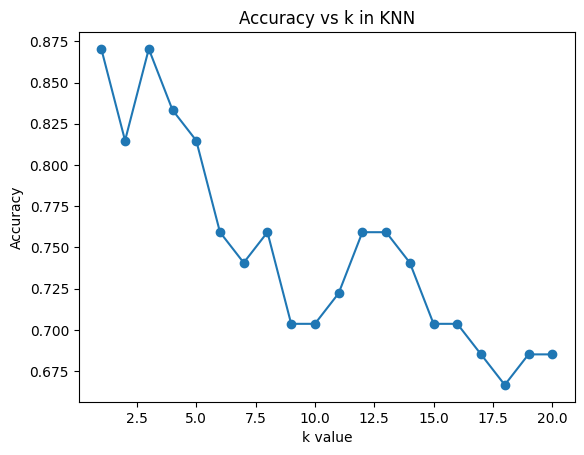

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k in KNN")
plt.show()